In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go
from scripts import FDD as fdd
import pandas as pd
from scipy.optimize import minimize

## **Loading all data**

In [2]:
eigvecs = np.load('../text_files/eigvecs_global.npy')

param_space2D = np.load("param_spaces/param_space2D.npy")
param_space_eigvecs2D = np.load("param_spaces/param_space_eigvecs2D.npy")

param_space3D = np.load("param_spaces/param_space.npy")
param_space_eigvecs3D = np.load("param_spaces/param_space_eigvecs.npy")

param_space3D_2 = np.load("param_spaces/param_space3D_2.npy")
param_space_eigvecs3D_2 = np.load("param_spaces/param_space_eigvecs3D_2.npy")


# **Applying mode flipping**

In [3]:
N_MODES = 6

THRESH_3D_STAGE1 = 0.3
THRESH_3D_STAGE2 = 0.5

HIGH = 0.6
LOW = 0.1

def swap_modes(phi, eigvals, a, b):
    phi = phi.copy()
    eigvals = eigvals.copy()

    phi[:, [a, b]] = phi[:, [b, a]]
    eigvals[[a, b]] = eigvals[[b, a]]

    return phi, eigvals


def move_mode(phi, eigvals, src, dst):
    phi = phi.copy()
    eigvals = eigvals.copy()

    phi[:, dst] = phi[:, src]
    eigvals[dst] = eigvals[src]

    return phi, eigvals


def compute_mac(ref, phi, n_modes):
    return fdd.compute_mac(ref, phi, n_modes=n_modes)

def apply_rules(ref, eigvecs_field, eigvals_field, n_modes=N_MODES):

    eigvecs_out = eigvecs_field.copy()
    eigvals_out = eigvals_field.copy()

    for idx in np.ndindex(eigvecs_field.shape[:-2]):
        phi = eigvecs_out[idx]
        eigvals = eigvals_out[idx]

        mac = compute_mac(ref, phi, n_modes)
        val = mac[3, 3]

        if val >= HIGH:
            pass

        elif val <= LOW:
            phi, eigvals = swap_modes(phi, eigvals, 3, 2)

        else:
            phi, eigvals = move_mode(phi, eigvals, 4, 2)

            temp_phi = eigvecs_out[idx][:, 2].copy()
            temp_eigval = eigvals_out[idx][2].copy()

            phi[:, 3] = temp_phi
            eigvals[3] = temp_eigval

        eigvecs_out[idx] = phi
        eigvals_out[idx] = eigvals

    return eigvecs_out, eigvals_out

def apply_rules_3D(ref, eigvecs_field, eigvals_field, n_modes=N_MODES):

    eigvecs_out = eigvecs_field.copy()
    eigvals_out = eigvals_field.copy()

    for idx in np.ndindex(eigvecs_field.shape[:-2]):

        phi = eigvecs_out[idx]
        eigvals = eigvals_out[idx]

        mac = compute_mac(ref, phi, n_modes)

        if mac[2, 2] < THRESH_3D_STAGE1:
            phi, eigvals = swap_modes(phi, eigvals, 2, 3)

            # recompute MAC after update
            mac = compute_mac(ref, phi, n_modes)

        if mac[2, 2] < THRESH_3D_STAGE2:
            phi, eigvals = swap_modes(phi, eigvals, 2, 4)

        eigvecs_out[idx] = phi
        eigvals_out[idx] = eigvals

    return eigvecs_out, eigvals_out

param_space_eigvecs2D_fixed, param_space_eigvals2D_fixed = apply_rules(
    eigvecs,
    param_space_eigvecs2D,
    param_space2D,
    n_modes=N_MODES
)

param_space_eigvecs3D_fixed, param_space_eigvals3D_fixed = apply_rules_3D(
    eigvecs,
    param_space_eigvecs3D,
    param_space3D,
    n_modes=N_MODES
)

param_space_eigvecs3D_2_fixed, param_space_eigvals3D_2_fixed = apply_rules(
    eigvecs,
    param_space_eigvecs3D_2,
    param_space3D_2,
    n_modes=N_MODES
)

np.save("param_spaces/param_space_eigvecs2D_fixed.npy", param_space_eigvecs2D_fixed)
np.save("param_spaces/param_space_eigvals2D_fixed.npy", param_space_eigvals2D_fixed)

np.save("param_spaces/param_space_eigvecs3D_fixed.npy", param_space_eigvecs3D_fixed)
np.save("param_spaces/param_space_eigvals3D_fixed.npy", param_space_eigvals3D_fixed)

np.save("param_spaces/param_space_eigvecs3D_2_fixed.npy", param_space_eigvecs3D_2_fixed)
np.save("param_spaces/param_space_eigvals3D_2_fixed.npy", param_space_eigvals3D_2_fixed)

## **Plotting MAC after correcting**

C:\Users\alami\AppData\Local\Temp\ipykernel_3984\1376117924.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


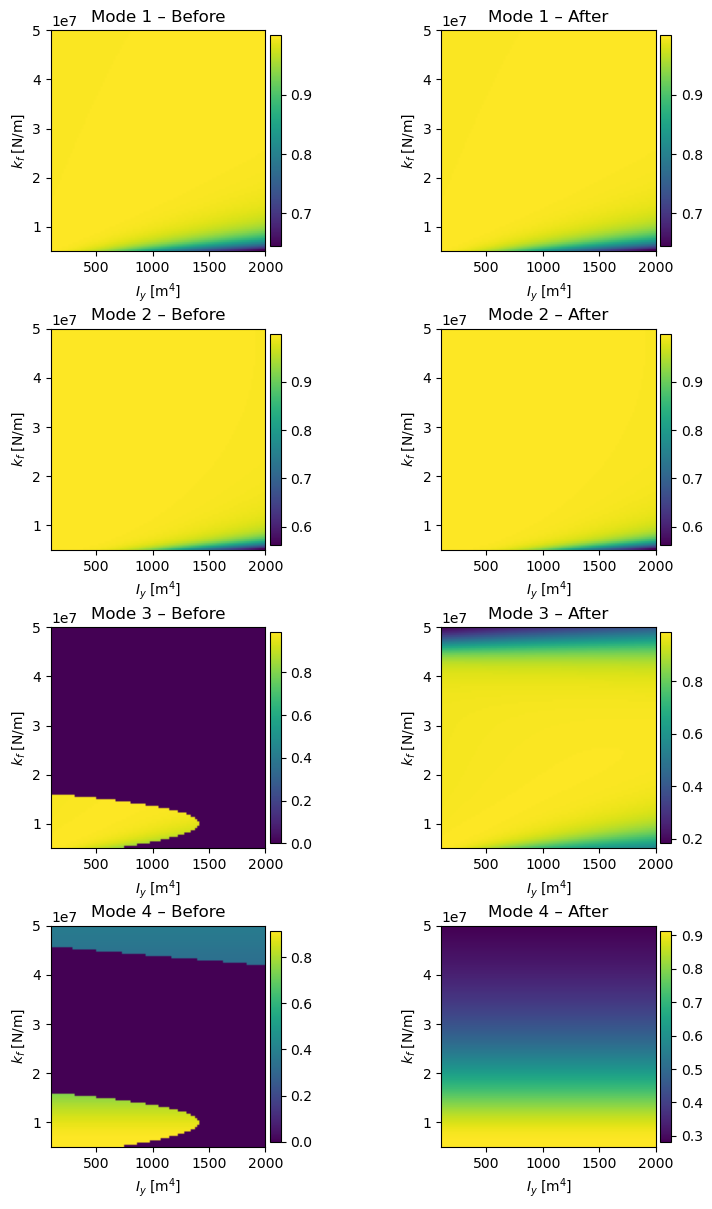

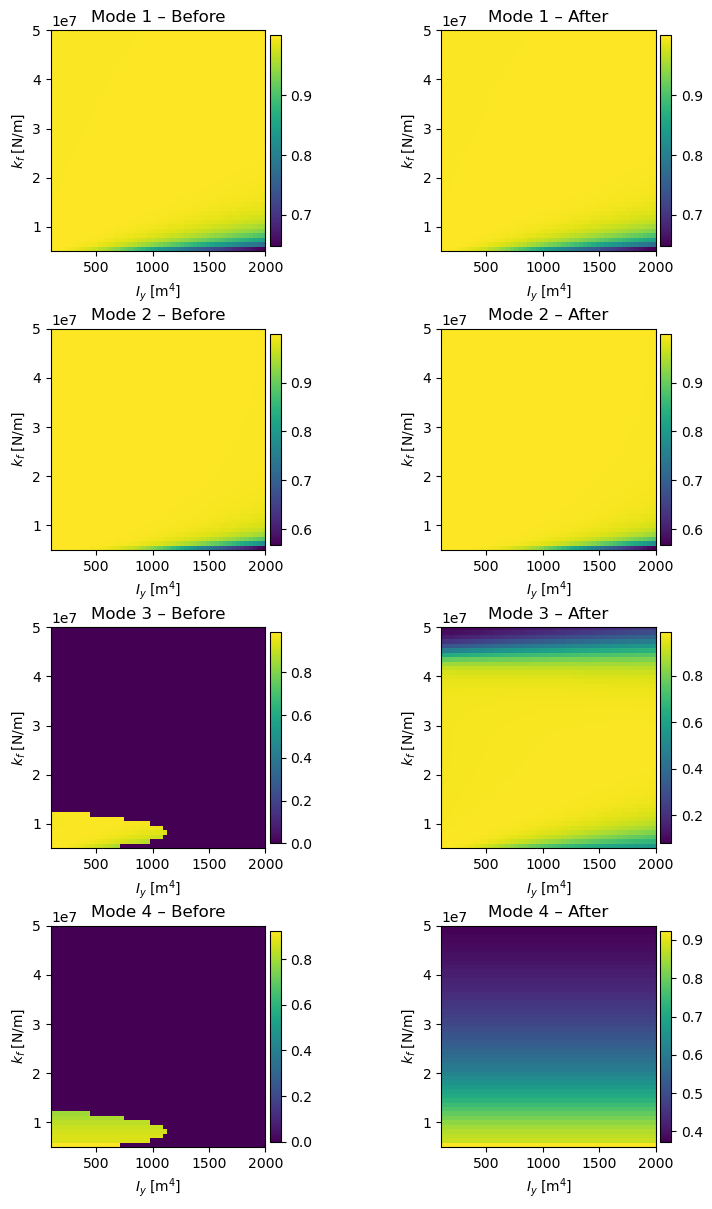

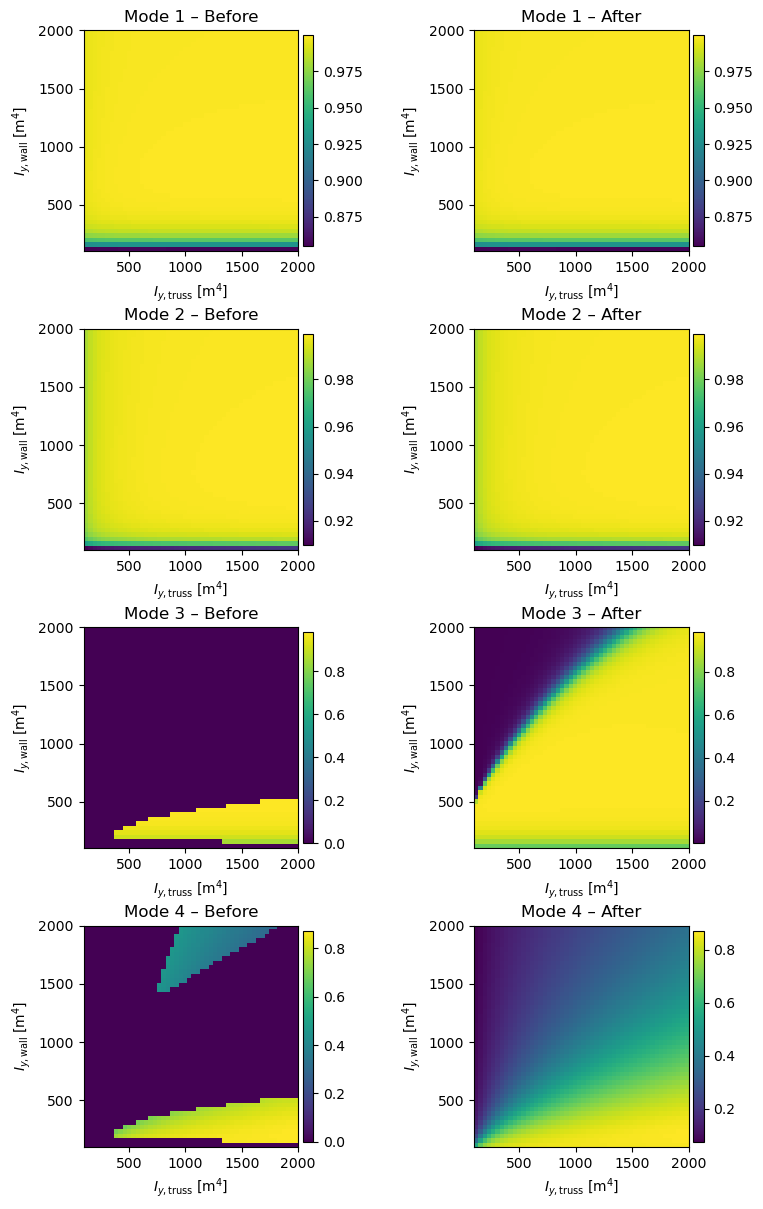

In [4]:

N_MODES = 6
PLOT_MODES = 4  # only plot first 4 modes



kf_min, kf_max = 5e6, 5e7
kl_min, kl_max = 0.2e10, 1e10

Iy_min, Iy_max = 100, 2000
Iy_wall_min, Iy_wall_max = 100, 2000



def extract_diag_maps_2d(ref, field, n_modes=N_MODES):
    out = [np.zeros(field.shape[:2]) for _ in range(n_modes)]

    for i in range(field.shape[0]):
        for j in range(field.shape[1]):
            mac = fdd.compute_mac(ref, field[i, j], n_modes=n_modes)
            for m in range(n_modes):
                out[m][i, j] = mac[m, m]

    return out


def extract_diag_maps_3d(ref, field, n_modes=N_MODES):
    out = [np.zeros(field.shape[:3]) for _ in range(n_modes)]

    for i in range(field.shape[0]):
        for j in range(field.shape[1]):
            for k in range(field.shape[2]):
                mac = fdd.compute_mac(ref, field[i, j, k], n_modes=n_modes)
                for m in range(n_modes):
                    out[m][i, j, k] = mac[m, m]

    return out


def plot_before_after(
    before,
    after,
    title,
    x_range,
    y_range,
    x_label,
    y_label,
    is_3d=False,
    save_path=None
):

    fig, axs = plt.subplots(
        PLOT_MODES, 2,
        figsize=(8, 14.5),
        gridspec_kw={'wspace': 0.7, 'hspace': 0.35}
    )

    for m in range(PLOT_MODES):

        mode_label = f"Mode {m+1}"

        # ---------------- BEFORE ----------------
        data_b = before[m]
        if is_3d:
            k = data_b.shape[2] // 2
            data_b = data_b[:, :, k]

        im0 = axs[m, 0].imshow(
            data_b,
            origin="lower",
            cmap="viridis",
            extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
            aspect="auto"
        )

        axs[m, 0].set_title(f"{mode_label} – Before")
        axs[m, 0].set_xlabel(x_label)
        axs[m, 0].set_ylabel(y_label)
        plt.colorbar(im0, ax=axs[m, 0], fraction=0.046, pad=0.02)

        # ---------------- AFTER ----------------
        data_a = after[m]
        if is_3d:
            k = data_a.shape[2] // 2
            data_a = data_a[:, :, k]

        im1 = axs[m, 1].imshow(
            data_a,
            origin="lower",
            cmap="viridis",
            extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
            aspect="auto"
        )

        axs[m, 1].set_title(f"{mode_label} – After")
        axs[m, 1].set_xlabel(x_label)
        axs[m, 1].set_ylabel(y_label)
        plt.colorbar(im1, ax=axs[m, 1], fraction=0.046, pad=0.02)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, format="pdf", bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ---------------- 2D (x=Iy, y=kf) ----------------
mac2D_before = extract_diag_maps_2d(eigvecs, param_space_eigvecs2D)
mac2D_after  = extract_diag_maps_2d(eigvecs, param_space_eigvecs2D_fixed)

plot_before_after(
    mac2D_before,
    mac2D_after,
    title="2D",
    x_range=(Iy_min, Iy_max),
    y_range=(kf_min, kf_max),
    x_label=r"$I_y\;[\mathrm{m}^4]$",
    y_label=r"$k_f\;[\mathrm{N/m}]$",
    is_3d=False,
)

# ---------------- 3D dataset 1 (x=Iy, y=kf) ----------------
mac3D_before = extract_diag_maps_3d(eigvecs, param_space_eigvecs3D)
mac3D_after  = extract_diag_maps_3d(eigvecs, param_space_eigvecs3D_fixed)

plot_before_after(
    mac3D_before,
    mac3D_after,
    title="3D dataset 1",
    x_range=(Iy_min, Iy_max),
    y_range=(kf_min, kf_max),
    x_label=r"$I_y\;[\mathrm{m}^4]$",
    y_label=r"$k_f\;[\mathrm{N/m}]$",
    is_3d=True,
)

# ---------------- 3D dataset 2 (x=Iy_truss, y=Iy_wall) ----------------
mac3D2_before = extract_diag_maps_3d(eigvecs, param_space_eigvecs3D_2)
mac3D2_after  = extract_diag_maps_3d(eigvecs, param_space_eigvecs3D_2_fixed)

plot_before_after(
    mac3D2_before,
    mac3D2_after,
    title="3D dataset 2",
    x_range=(Iy_min, Iy_max),
    y_range=(Iy_wall_min, Iy_wall_max),
    x_label=r"$I_{y,\mathrm{truss}}\;[\mathrm{m}^4]$",
    y_label=r"$I_{y,\mathrm{wall}}\;[\mathrm{m}^4]$",
    is_3d=True,
)